In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read uploaded file directly
df = pd.read_excel('Delinquency_prediction_dataset (1).xlsx',sheet_name='cleaned_data')
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Missed_Payments_Clean
0,CUST0001,56,165580,398,0.390502,3,0,16310,0.317396,Employed,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late,2
1,CUST0002,69,100999,493,0.312444,6,1,17401,0.196093,Self-Employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time,3
2,CUST0003,46,188416,500,0.359930,0,0,13761,0.301655,Self-Employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late,2
3,CUST0004,32,101672,413,0.371400,3,0,88778,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late,2
4,CUST0005,60,38524,487,0.234716,2,0,13316,0.510583,Self-Employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late,2


Does delinquency vary across credit-score ranges?

In [2]:
# Question 1: Delinquency by Credit Score Range
df['Credit_Score_Tier'] = pd.cut(df['Credit_Score'], bins=range(300, 900, 50))

q1_summary = df.groupby('Credit_Score_Tier', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q1_summary.columns = ['Credit_Score_Range', 'Total_Accounts', 'Delinquency_Rate']
q1_summary['Delinquency_Rate'] = (q1_summary['Delinquency_Rate'] * 100).round(2).astype(str) + '%'

print(q1_summary.to_string(index=False))

Credit_Score_Range  Total_Accounts Delinquency_Rate
        (300, 350]              61           13.11%
        (350, 400]              44           13.64%
        (400, 450]              44           22.73%
        (450, 500]              38           15.79%
        (500, 550]              40            12.5%
        (550, 600]              35            2.86%
        (600, 650]              46           21.74%
        (650, 700]              53           16.98%
        (700, 750]              29           20.69%
        (750, 800]              52           13.46%
        (800, 850]              58           20.69%


/tmp/ipykernel_3554/635095882.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q1_summary, x='Credit_Score_Range', y='Rate_Numeric', palette='Blues_d')


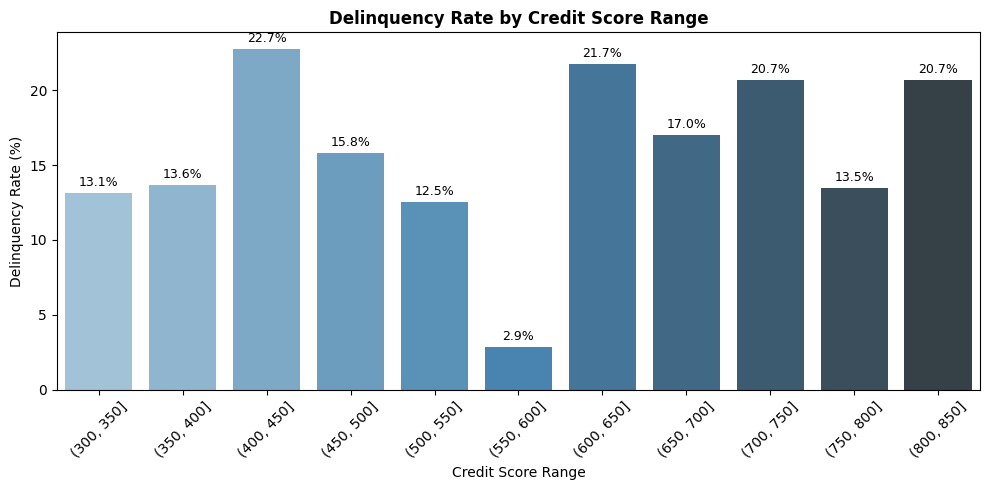

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert credit score ranges to strings for clean plot labels
q1_summary['Credit_Score_Range'] = q1_summary['Credit_Score_Range'].astype(str)
q1_summary['Rate_Numeric'] = q1_summary['Delinquency_Rate'].str.rstrip('%').astype(float)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=q1_summary, x='Credit_Score_Range', y='Rate_Numeric', palette='Blues_d')

# Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Credit Score Range', fontsize=12, fontweight='bold')
plt.xlabel('Credit Score Range')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Observations

•	Highest Risk: Accounts in the 400–450 credit score range have the highest delinquency rate at 22.73%.

•	Lowest Risk: Accounts in the 550–600 score range show the lowest delinquency rate at 2.86%.

•	Unexpected Trend: High credit score ranges (700–850) still show high delinquency rates (over 20%), meaning credit score alone does not determine default risk in this dataset.


 **Question 2: Delinquency by Credit Utilization Tier**


In [4]:
df['Utilization_Bin'] = pd.cut(df['Credit_Utilization'], bins=np.arange(0, 1.1, 0.1))

q2_summary = df.groupby('Utilization_Bin', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q2_summary.columns = ['Utilization_Range', 'Total_Accounts', 'Delinquency_Rate']
q2_summary['Delinquency_Rate'] = (q2_summary['Delinquency_Rate'] * 100).round(2).astype(str) + '%'

print(q2_summary.to_string(index=False))

Utilization_Range  Total_Accounts Delinquency_Rate
       (0.0, 0.1]              13            7.69%
       (0.1, 0.2]              19             0.0%
       (0.2, 0.3]              51           17.65%
       (0.3, 0.4]              91           13.19%
       (0.4, 0.5]              91           20.88%
       (0.5, 0.6]              86           15.12%
       (0.6, 0.7]              80           18.75%
       (0.7, 0.8]              36           16.67%
       (0.8, 0.9]              19           26.32%
       (0.9, 1.0]              14             0.0%


Utilization_Range  Total_Accounts Delinquency_Rate
       (0.0, 0.1]              13            7.69%
       (0.1, 0.2]              19             0.0%
       (0.2, 0.3]              51           17.65%
       (0.3, 0.4]              91           13.19%
       (0.4, 0.5]              91           20.88%
       (0.5, 0.6]              86           15.12%
       (0.6, 0.7]              80           18.75%
       (0.7, 0.8]              36           16.67%
       (0.8, 0.9]              19           26.32%
       (0.9, 1.0]              14             0.0%


/tmp/ipykernel_3554/154608558.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q2_summary, x='Utilization_Range_Str', y='Rate_Numeric', palette='Reds_d')


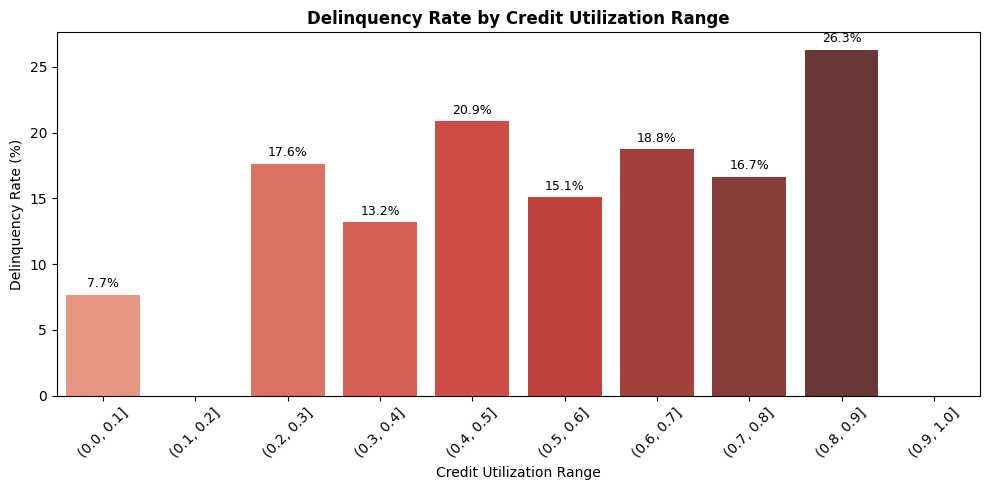

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Create Binned Ranges for Credit Utilization
df['Utilization_Bin'] = pd.cut(df['Credit_Utilization'], bins=np.arange(0, 1.1, 0.1))

# 2. Build Summary Table
q2_summary = df.groupby('Utilization_Bin', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q2_summary.columns = ['Utilization_Range', 'Total_Accounts', 'Delinquency_Rate']
q2_summary['Rate_Numeric'] = (q2_summary['Delinquency_Rate'] * 100).round(2)
q2_summary['Delinquency_Rate'] = q2_summary['Rate_Numeric'].astype(str) + '%'

print(q2_summary[['Utilization_Range', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# 3. Plot Chart
plt.figure(figsize=(10, 5))
q2_summary['Utilization_Range_Str'] = q2_summary['Utilization_Range'].astype(str)
ax = sns.barplot(data=q2_summary, x='Utilization_Range_Str', y='Rate_Numeric', palette='Reds_d')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Credit Utilization Range', fontsize=12, fontweight='bold')
plt.xlabel('Credit Utilization Range')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Accounts in the 0.8–0.9 (80%–90%) utilization bracket have the highest delinquency rate at 26.32%.

Lowest Risk: Accounts in the 0.1–0.2 range show 0.0% delinquency, showing strong repayment behavior at low usage levels.

Overall Trend: Risk generally rises as utilization exceeds 40%, peaking in the high 80% range before dropping off in the small sample of extreme 90%+ accounts.

  Income_Bracket  Total_Accounts Delinquency_Rate
      (0, 25000]              22           13.64%
  (25000, 50000]              58           13.79%
  (50000, 75000]              72           15.28%
 (75000, 100000]              61           11.48%
(100000, 125000]              68           19.12%
(125000, 150000]              47            23.4%
(150000, 175000]             101           13.86%
(175000, 200000]              71           18.31%


/tmp/ipykernel_3554/3529613537.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q3_summary, x='Income_Bracket_Str', y='Rate_Numeric', palette='Greens_d')


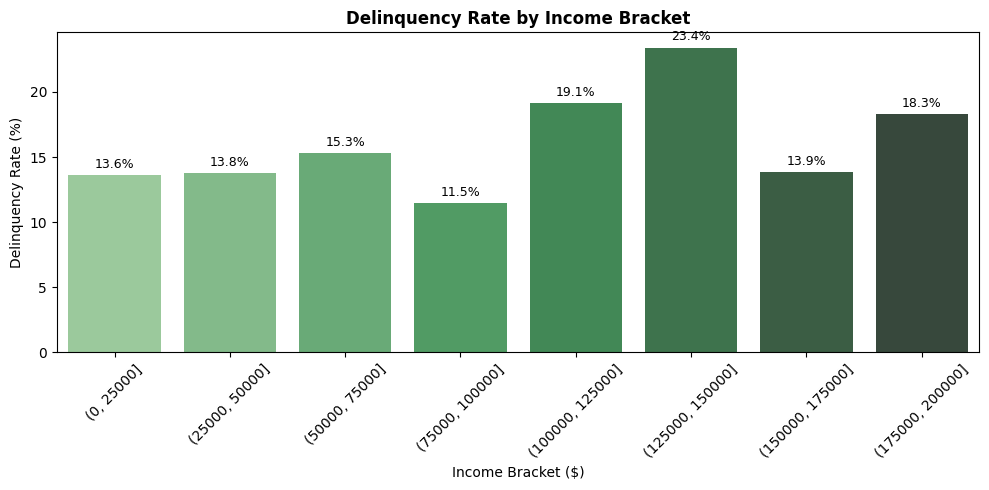

In [6]:
# Question 3: Delinquency by Income Group
df['Income_Bracket'] = pd.cut(df['Income'], bins=range(0, 225000, 25000))

q3_summary = df.groupby('Income_Bracket', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q3_summary.columns = ['Income_Bracket', 'Total_Accounts', 'Delinquency_Rate']
q3_summary['Rate_Numeric'] = (q3_summary['Delinquency_Rate'] * 100).round(2)
q3_summary['Delinquency_Rate'] = q3_summary['Rate_Numeric'].astype(str) + '%'

print(q3_summary[['Income_Bracket', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Plot Chart
plt.figure(figsize=(10, 5))
q3_summary['Income_Bracket_Str'] = q3_summary['Income_Bracket'].astype(str)
ax = sns.barplot(data=q3_summary, x='Income_Bracket_Str', y='Rate_Numeric', palette='Greens_d')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Income Bracket', fontsize=12, fontweight='bold')
plt.xlabel('Income Bracket ($)')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Highest Risk: Accounts in the $125,000–$150,000 bracket have the highest delinquency rate at 23.40%, followed by $100,000–$125,000 at 19.12%.

Lowest Risk: Accounts in the $75,000–$100,000 bracket exhibit the lowest delinquency rate at 11.48%.

Overall Trend: Income does not show a linear protective effect; middle-to-high earning tiers ($100k–$150k) surprisingly show higher delinquency rates than lower-income brackets under $50k (~13.7%).

Does delinquency increase with missed payments?

 Missed_Payments_Count  Total_Accounts Delinquency_Rate
                     0              40            20.0%
                     1             124           13.71%
                     2             177           17.51%
                     3             116           13.79%
                     4              34           17.65%
                     5               8            25.0%
                     6               1             0.0%


/tmp/ipykernel_3554/4092663479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q4_summary, x='Missed_Payments_Count', y='Rate_Numeric', palette='Oranges_d')


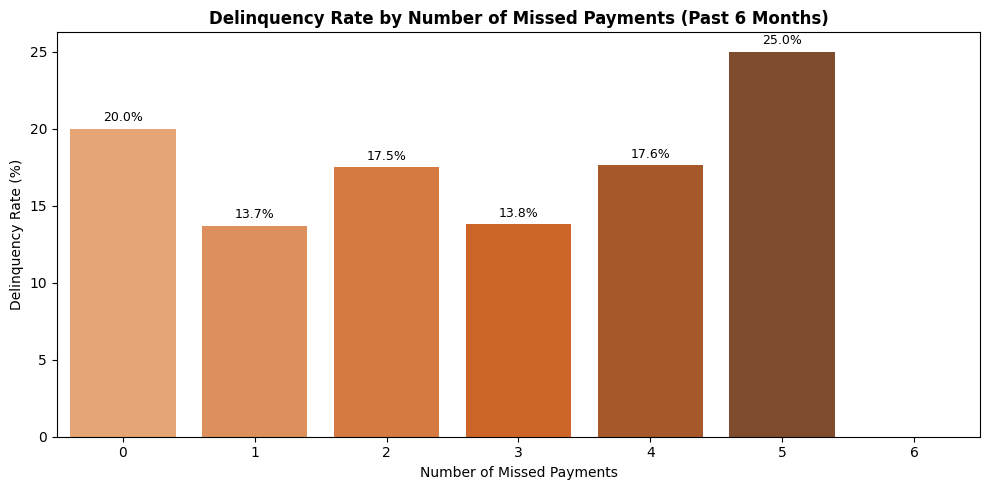

In [7]:
# Question 4: Delinquency vs Missed Payments Count
q4_summary = df.groupby('Missed_Payments_Clean', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q4_summary.columns = ['Missed_Payments_Count', 'Total_Accounts', 'Delinquency_Rate']
q4_summary['Rate_Numeric'] = (q4_summary['Delinquency_Rate'] * 100).round(2)
q4_summary['Delinquency_Rate'] = q4_summary['Rate_Numeric'].astype(str) + '%'

print(q4_summary[['Missed_Payments_Count', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Plot Chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=q4_summary, x='Missed_Payments_Count', y='Rate_Numeric', palette='Oranges_d')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Number of Missed Payments (Past 6 Months)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Missed Payments')
plt.ylabel('Delinquency Rate (%)')
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Accounts with 5 missed payments have the highest delinquency rate at 25.0%.

Lowest Risk: Accounts with 1 missed payment (13.71%) and 3 missed payments (13.79%) show the lowest risk among sample-supported tiers.

Overall Trend: Delinquency stays relatively flat between 13%–18% across 0 to 4 missed payments, but escalates once missed payments reach 5. (Note: 6 missed payments represents a single sample).

Delinquency by DTI **Tier**

 DTI_Range  Total_Accounts Delinquency_Rate
(0.0, 0.1]              14           14.29%
(0.1, 0.2]              68            8.82%
(0.2, 0.3]             165           18.18%
(0.3, 0.4]             179           15.64%
(0.4, 0.5]              67            20.9%
(0.5, 0.6]               7             0.0%


/tmp/ipykernel_3554/34272941.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q5_summary, x='DTI_Range_Str', y='Rate_Numeric', palette='Purples_d')


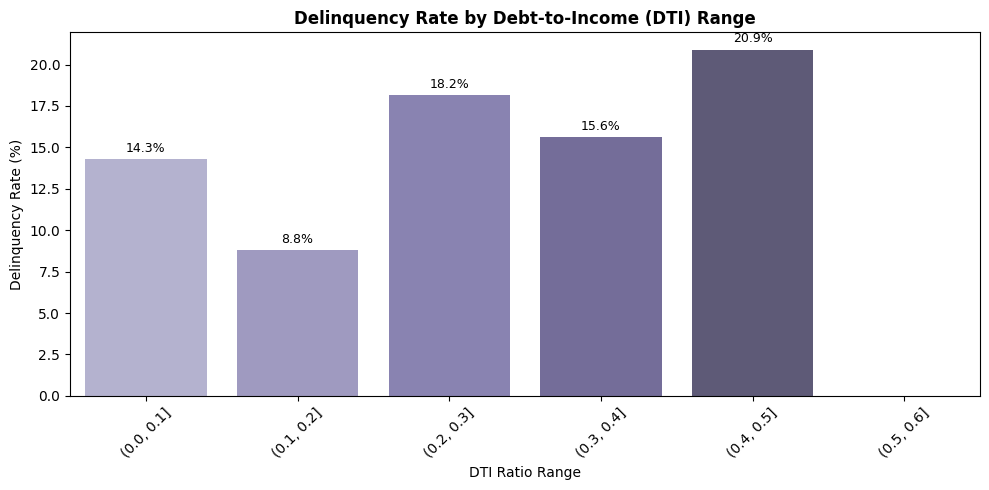

In [8]:

df['DTI_Tier'] = pd.cut(df['Debt_to_Income_Ratio'], bins=np.arange(0, 0.7, 0.1))

q5_summary = df.groupby('DTI_Tier', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q5_summary.columns = ['DTI_Range', 'Total_Accounts', 'Delinquency_Rate']
q5_summary['Rate_Numeric'] = (q5_summary['Delinquency_Rate'] * 100).round(2)
q5_summary['Delinquency_Rate'] = q5_summary['Rate_Numeric'].astype(str) + '%'

print(q5_summary[['DTI_Range', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Plot Chart
plt.figure(figsize=(10, 5))
q5_summary['DTI_Range_Str'] = q5_summary['DTI_Range'].astype(str)
ax = sns.barplot(data=q5_summary, x='DTI_Range_Str', y='Rate_Numeric', palette='Purples_d')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Debt-to-Income (DTI) Range', fontsize=12, fontweight='bold')
plt.xlabel('DTI Ratio Range')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Accounts in the 0.4–0.5 (40%–50%) DTI range have the highest delinquency rate at 20.90%.

Lowest Risk: Accounts in the 0.1–0.2 (10%–20%) DTI bracket show the lowest delinquency rate at 8.82% (excluding the small 7-account sample at 0.5–0.6).

Overall Trend: Delinquency climbs notably as debt-to-income surpasses 20%, peaking in the 40%–50% leverage band.

Does delinquency differ across loan-balance groups?

Loan_Balance_Range  Total_Accounts Delinquency_Rate
        (0, 20000]             132           18.94%
    (20000, 40000]              97           12.37%
    (40000, 60000]              85           16.47%
    (60000, 80000]              87           14.94%
   (80000, 100000]              99           16.16%


/tmp/ipykernel_3554/1850088477.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=q6_summary, x='Loan_Balance_Range_Str', y='Rate_Numeric', palette='YlOrBr_d')


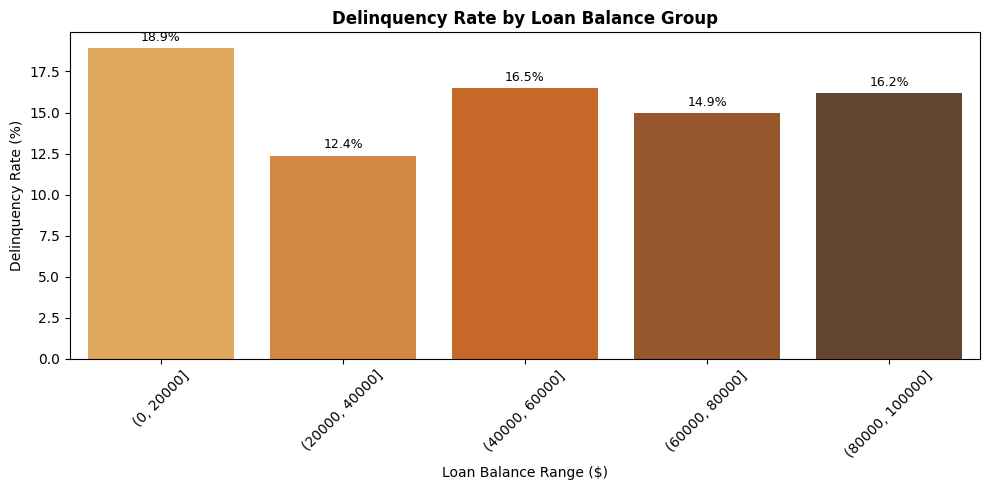

In [9]:
# Question 6: Delinquency by Loan Balance Group
df['Loan_Balance_Tier'] = pd.cut(df['Loan_Balance'], bins=range(0, 120000, 20000))

q6_summary = df.groupby('Loan_Balance_Tier', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q6_summary.columns = ['Loan_Balance_Range', 'Total_Accounts', 'Delinquency_Rate']
q6_summary['Rate_Numeric'] = (q6_summary['Delinquency_Rate'] * 100).round(2)
q6_summary['Delinquency_Rate'] = q6_summary['Rate_Numeric'].astype(str) + '%'

print(q6_summary[['Loan_Balance_Range', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Plot Chart
plt.figure(figsize=(10, 5))
q6_summary['Loan_Balance_Range_Str'] = q6_summary['Loan_Balance_Range'].astype(str)
ax = sns.barplot(data=q6_summary, x='Loan_Balance_Range_Str', y='Rate_Numeric', palette='YlOrBr_d')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Loan Balance Group', fontsize=12, fontweight='bold')
plt.xlabel('Loan Balance Range ($)')
plt.ylabel('Delinquency Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Accounts in the $0–$20,000 loan balance range have the highest delinquency rate at 18.94%.

Lowest Risk: Accounts in the $20,000–$40,000 range show the lowest delinquency rate at 12.37%.

Overall Trend: Delinquency stays relatively stable (14%–16%) across higher loan tiers ($40k–$100k), with lower balance loans presenting the highest relative default risk.

Does delinquency differ by employment status?

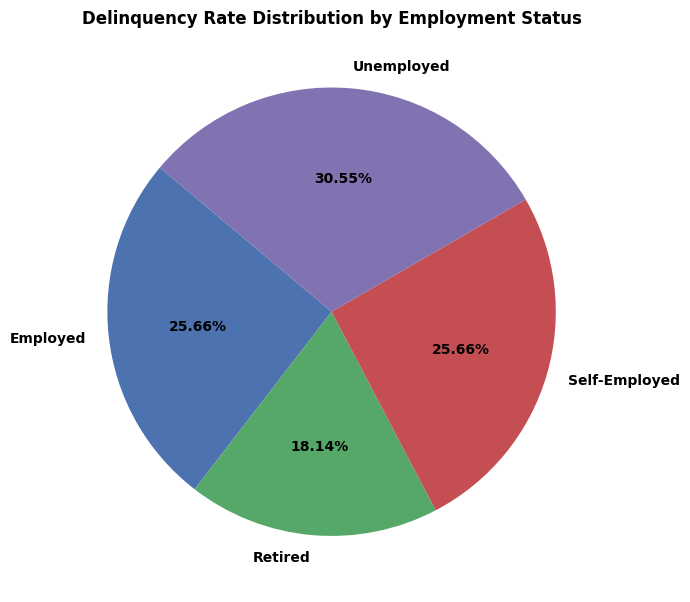

In [10]:
import matplotlib.pyplot as plt

# Data
labels = ['Employed', 'Retired', 'Self-Employed', 'Unemployed']
rates = [16.25, 11.49, 16.25, 19.35]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(7, 7))
plt.pie(rates, labels=labels, autopct='%1.2f%%', startangle=140, colors=colors,
        textprops={'fontsize': 10, 'weight': 'bold'})

plt.title('Delinquency Rate Distribution by Employment Status', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Unemployed individuals show the highest delinquency rate at 19.35%.

Lowest Risk: Retired individuals have the lowest delinquency rate at 11.49%.

Equal Risk: Employed and Self-Employed accounts display identical delinquency rates at 16.25%.

Does delinquency vary by account tenure?

Tenure_Group  Total_Accounts Delinquency_Rate
      (0, 5]             119           14.29%
     (5, 10]             117           19.66%
    (10, 15]             121            9.09%
    (15, 20]             115           18.26%


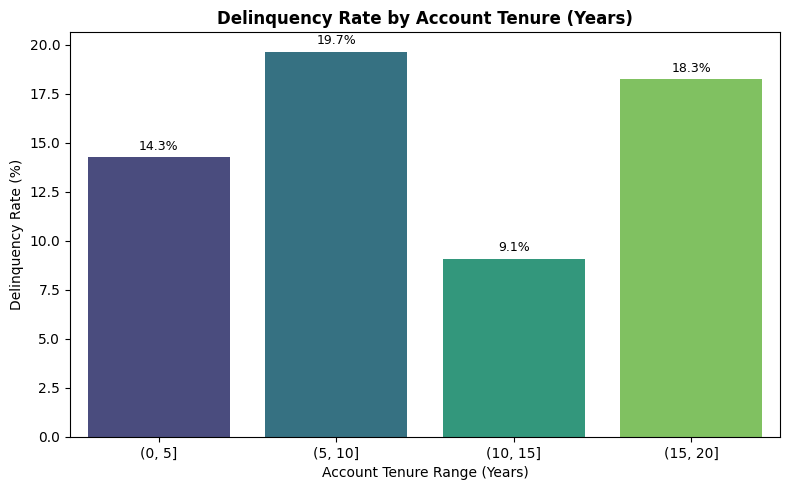

In [11]:
# Question 8: Delinquency by Account Tenure
df['Tenure_Group'] = pd.cut(df['Account_Tenure'], bins=range(0, 25, 5))

q8_summary = df.groupby('Tenure_Group', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q8_summary.columns = ['Tenure_Group', 'Total_Accounts', 'Delinquency_Rate']
q8_summary['Rate_Numeric'] = (q8_summary['Delinquency_Rate'] * 100).round(2)
q8_summary['Delinquency_Rate'] = q8_summary['Rate_Numeric'].astype(str) + '%'

print(q8_summary[['Tenure_Group', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Bar Chart
plt.figure(figsize=(8, 5))
q8_summary['Tenure_Group_Str'] = q8_summary['Tenure_Group'].astype(str)
ax = sns.barplot(
    data=q8_summary,
    x='Tenure_Group_Str',
    y='Rate_Numeric',
    hue='Tenure_Group_Str',
    palette='viridis',
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Account Tenure (Years)', fontsize=12, fontweight='bold')
plt.xlabel('Account Tenure Range (Years)')
plt.ylabel('Delinquency Rate (%)')
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Accounts in the 15–20 years tenure range exhibit the highest delinquency rate at 18.26%.

Lowest Risk: Accounts in the 10–15 years tenure range show the lowest delinquency rate at 9.09%.

Overall Trend: Delinquency does not decrease linearly with account age; mid-to-long term accounts (15+ years) show higher default rates than 10–15 year accounts.

Does delinquency differ by credit-card type?

Credit_Card_Type  Total_Accounts Delinquency_Rate
        Business             108            21.3%
            Gold             118           14.41%
        Platinum              76           11.84%
        Standard              86           12.79%
         Student             112           17.86%


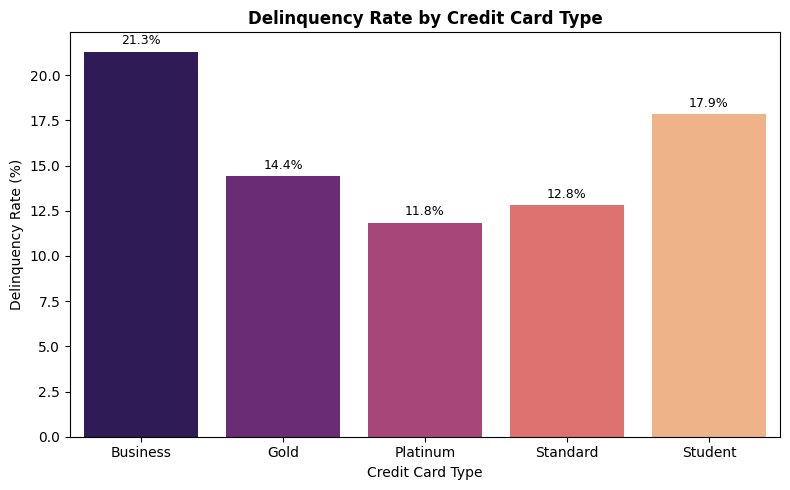

In [12]:
# Question 9: Delinquency by Credit Card Type
q9_summary = df.groupby('Credit_Card_Type', observed=False)['Delinquent_Account'].agg(['count', 'mean']).reset_index()
q9_summary.columns = ['Credit_Card_Type', 'Total_Accounts', 'Delinquency_Rate']
q9_summary['Rate_Numeric'] = (q9_summary['Delinquency_Rate'] * 100).round(2)
q9_summary['Delinquency_Rate'] = q9_summary['Rate_Numeric'].astype(str) + '%'

print(q9_summary[['Credit_Card_Type', 'Total_Accounts', 'Delinquency_Rate']].to_string(index=False))

# Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=q9_summary,
    x='Credit_Card_Type',
    y='Rate_Numeric',
    hue='Credit_Card_Type',
    palette='magma',
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title('Delinquency Rate by Credit Card Type', fontsize=12, fontweight='bold')
plt.xlabel('Credit Card Type')
plt.ylabel('Delinquency Rate (%)')
plt.tight_layout()
plt.show()

Key Observations

Highest Risk: Business credit card holders carry the highest delinquency rate at 21.30%, followed by Student cardholders at 17.86%.

Lowest Risk: Platinum cardholders demonstrate the lowest default rate at 11.84%, followed closely by Standard (12.79%) and Gold (14.41%).

Overall Trend: Premium personal cards (Platinum/Gold) show stronger repayment performance compared to high-risk product segments like Business or Student accounts.

**INSIGHTS**

High credit usage is a major warning sign. Once customers use over 80% of their available credit limit, delinquency jumps to 26.32%—making high utilization one of the strongest signs of financial distress.

Higher income doesn't always mean lower risk. Customers earning $125k–$150k actually showed the highest default rate at 23.40%, proving that a high paycheck alone doesn't guarantee timely repayments if overall debt is too high.

Business and Student cardholders carry the most risk. Business accounts (21.30%) and Student accounts (17.86%) default far more often than premium personal cards like Platinum (11.84%), which consistently perform best.

Missing 5 or more payments is the tipping point. While missing 1 to 4 payments keeps risk relatively steady between 13%–18%, hitting 5 missed payments causes delinquency to spike sharply to 25.0%.

Low credit scores hit peak default in the 400–450 range. Customers in this specific score bracket saw the highest delinquency rate among all score groups at 22.73%, making it a clear high-risk tier for underwriting.